# Batch Predictions with Prefect

This notebook shows how the registered MLflow model is reused in a batch workflow. Instead of retraining, we load the model from MLflow and score a whole Parquet file with the Prefect flow used by the project.

Before you run it, finish [02-train-ml-model.ipynb](02-train-ml-model.ipynb) so MLflow already has at least one registered model version to resolve.


## Workflow

```mermaid
flowchart LR
    A["Batch input<br>Parquet"] --> B["Prefect<br>flow"]
    B --> C["Resolve latest model<br>from MLflow"]
    C --> D["Score every<br>ride record"]
    D --> E["Write prediction<br>Parquet"]
```


In [1]:
from pathlib import Path

import pandas as pd

from src.batch.flow import score_batch_flow
from src.common.config import get_settings

settings = get_settings()
output_path = Path("data/predictions/notebook_batch_predictions.parquet")
settings

ProjectSettings(mlflow_tracking_uri='http://127.0.0.1:5001', prefect_api_url='http://127.0.0.1:4200/api', experiment_name='green-taxi-duration', registered_model_name='green-taxi-duration', model_uri=None, model_alias=None, model_stage=None, model_version=None, run_id=None, model_artifact_path='model', train_data_uri='https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet', batch_input_uri='https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet', batch_output_dir=WindowsPath('E:/Workspace/neufishe/module3/mle-batch-and-stream-predictions/data/predictions'), artifacts_dir=WindowsPath('E:/Workspace/neufishe/module3/mle-batch-and-stream-predictions/storage/mlartifacts'))

## Run One Local Batch Flow

The flow reads the input Parquet file, resolves the latest registered model in MLflow, and writes a prediction Parquet file to the local `data/predictions/` directory.

In [2]:
result_path = score_batch_flow(
    input_uri=settings.batch_input_uri,
    output_path=str(output_path),
)
result_path

10:53:48.017 | INFO    | Flow run 'voracious-mole' - Beginning flow run 'voracious-mole' for flow 'score-green-taxi-batch'

10:53:48.087 | INFO    | Flow run 'voracious-mole' - View at http://127.0.0.1:4200/runs/flow-run/997dd8fd-05c4-4238-bd44-cf047d6c8ad2

10:53:48.944 | INFO    | Task run 'score_dataframe-c13' - Reading input from https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet

10:53:58.417 | INFO    | Task run 'score_dataframe-c13' - Loading model from models:/green-taxi-duration/2

10:55:40.257 | INFO    | Task run 'score_dataframe-c13' - Saved predictions to data\predictions\notebook_batch_predictions.parquet

10:55:40.599 | INFO    | Task run 'score_dataframe-c13' - Finished in state Completed()

10:55:42.053 | INFO    | Flow run 'voracious-mole' - Finished in state Completed()

'data\\predictions\\notebook_batch_predictions.parquet'

In [3]:
predictions = pd.read_parquet(result_path)
predictions.head()

,ride_id,lpep_pickup_datetime,PULocationID,DOLocationID,trip_distance,predicted_duration,model_reference,actual_duration,diff
0,697a327c-426f-4d67-92c6-d61656b52101,2025-02-01 00:12:15,166,41,0.65,6.336325,models:/green-taxi-duration/2,3.550000,-2.786325
1,fe42e2ea-e068-4b95-a889-77710ce6e659,2025-01-31 23:57:05,255,161,6.57,26.510471,models:/green-taxi-duration/2,27.316667,0.806196
2,7b9a367e-df8c-493f-af30-e65d72f784f0,2025-02-01 00:24:26,75,182,8.36,23.124131,models:/green-taxi-duration/2,25.466667,2.342536
3,3877743a-db18-4d5a-b882-6fae1f0313ff,2025-02-01 00:17:15,97,209,2.40,14.935642,models:/green-taxi-duration/2,8.683333,-6.252308
4,a2cf82f2-87de-4313-a5be-155b3cb44e3f,2025-02-01 00:17:36,7,223,1.31,9.188274,models:/green-taxi-duration/2,9.000000,-0.188274


## Interpret the Batch Output

Because this sample input still contains the observed trip duration, the output file includes both actual and predicted values. That gives us a quick way to check whether the batch run looks reasonable.

In [4]:
summary = pd.DataFrame(
    {
        "rows": [len(predictions)],
        "mean_actual_duration": [predictions["actual_duration"].mean()],
        "mean_predicted_duration": [predictions["predicted_duration"].mean()],
        "mean_absolute_error": [
            (predictions["actual_duration"] - predictions["predicted_duration"])
            .abs()
            .mean()
        ],
    }
)
summary

,rows,mean_actual_duration,mean_predicted_duration,mean_absolute_error
0,42588,13.68185,13.396072,3.260534


## Add One Helpful Comparison

Averages can hide a few large misses. The next cell surfaces the biggest absolute errors so you can inspect whether those rows look unusual.

In [5]:
largest_errors = predictions.assign(
    absolute_error=(
        predictions["actual_duration"] - predictions["predicted_duration"]
    ).abs()
).sort_values("absolute_error", ascending=False)

largest_errors[
    [
        "ride_id",
        "PULocationID",
        "DOLocationID",
        "trip_distance",
        "actual_duration",
        "predicted_duration",
        "absolute_error",
    ]
].head(10)

,ride_id,PULocationID,DOLocationID,trip_distance,actual_duration,predicted_duration,absolute_error
41956,53a5e1e6-4168-420c-846a-19dbf73e1583,65,177,44.62,28.000000,133.580774,105.580774
42269,e5c2700d-5278-4005-b384-f01f15f0dec1,23,265,43.15,59.566667,117.979177,58.412511
41949,48223b4c-c56b-428e-b94b-eec7902174ac,42,132,2.85,43.000000,-14.343232,57.343232
41763,d4a2deb6-aa63-44ef-9ad3-98b030fb349c,189,17,24.40,13.000000,69.488228,56.488228
41922,43269255-6445-416e-bff4-c0e400d56ad7,171,92,11.81,9.000000,64.821801,55.821801
38229,5d1e1bb6-5d78-40ac-9b38-d7f159898fcb,66,132,27.26,6.666667,62.182839,55.516172
42575,c9ad6dc2-3514-4bef-85d5-d10646175fef,42,42,0.97,59.833333,5.904476,53.928858
42485,6b0e7450-4931-44c7-b61d-dc0583effed0,75,74,0.96,59.350000,5.505794,53.844206
42243,a7a215ea-284b-4274-a4b4-00f68c5b1781,74,41,0.69,59.833333,6.268174,53.565159
41072,50930aab-4a9f-4135-8ebe-897fb73f516e,189,1,35.16,44.000000,97.315567,53.315567


## Visual Check: Actual vs Predicted Duration

A quick scatter plot gives a better intuition than a summary statistic alone. Points close to the diagonal line indicate trips where the batch prediction was close to the observed duration.

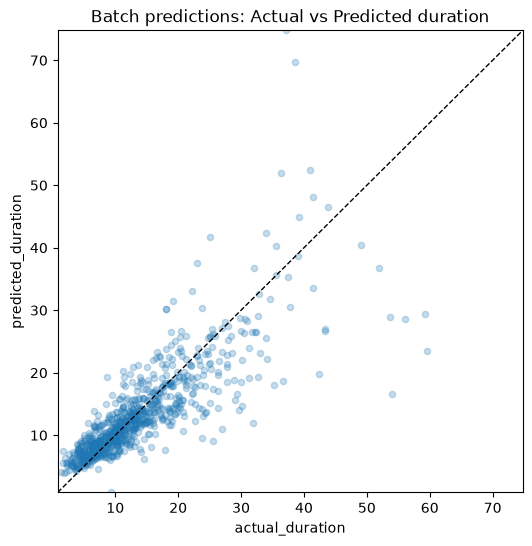

In [6]:
import matplotlib.pyplot as plt

sample_for_plot = predictions.sample(min(len(predictions), 800), random_state=42)
ax = sample_for_plot.plot.scatter(
    x="actual_duration",
    y="predicted_duration",
    alpha=0.25,
    figsize=(6, 6),
    title="Batch predictions: Actual vs Predicted duration",
)
limits = [
    min(
        sample_for_plot["actual_duration"].min(),
        sample_for_plot["predicted_duration"].min(),
    ),
    max(
        sample_for_plot["actual_duration"].max(),
        sample_for_plot["predicted_duration"].max(),
    ),
]
ax.plot(limits, limits, linestyle="--", color="black", linewidth=1)
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

## Schedule the Same Flow

The notebook runs the flow once. To keep it on a schedule, use the project helper below in a terminal:

```bash
uv run python -m src.batch.serve
```

That command starts a Prefect deployment using the cron expression from `.env`. It keeps running so Prefect can poll for scheduled runs; press `Ctrl + C` when you want to stop serving the deployment. If it fails, confirm that the local Prefect server is running and that `PREFECT_API_URL` still matches your local stack.
